# Figure 2: Human-LLM Divergence vs. Community Consensus

Shows that LLM divergence widens monotonically as community consensus strengthens—
the inverse of what calibrated uncertainty would produce.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Publication settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

BASE = Path('../data')
FIGURES = Path('../figures')

## Load Data

In [ ]:
# Load post consensus data
consensus_df = pd.read_csv(BASE / 'defamiliarization/post_consensus.csv')
print(f"Posts with consensus data: {len(consensus_df)}")

# Load comments to get top human response leave ratio per post
comments = pd.read_parquet(BASE / 'r_relationship_advice_comments_cleaned.parquet')
comments['post_id'] = comments['link_id'].str.replace('t3_', '', regex=False)

# Load LLM advice from parquet (wide format)
llm_df = pd.read_parquet(BASE / 'llm_advice.parquet')
print(f"LLM advice posts: {len(llm_df)}")

# Map column names to display names
MODEL_MAP = {
    'google_gemini-2-5-flash-lite': 'Gemini',
    'deepseek_deepseek-chat-v3-0324': 'DeepSeek',
    'mistralai_ministral-8b': 'Ministral',
    'openai_gpt-4-1-nano': 'GPT-4.1-nano',
}

# Convert wide format to dict of {model: {post_id: response}}
llm_responses = {}
for model_key, display_name in MODEL_MAP.items():
    response_col = f'{model_key}_response'
    if response_col in llm_df.columns:
        responses = llm_df[['post_id', response_col]].dropna(subset=[response_col])
        llm_responses[display_name] = dict(zip(responses['post_id'], responses[response_col]))
        print(f"{display_name}: {len(llm_responses[display_name])} responses")

## Define Leave/Stay Lexicons

In [13]:
LEAVE_PATTERNS = [
    r'\bleave\b', r'\bdump\b', r'\bbreak up\b', r'\bbreakup\b', r'\bdivorce\b',
    r'\bwalk away\b', r'\bget out\b', r'\brun\b', r'\bmove on\b', r'\bend it\b',
    r'\bend the relationship\b', r'\bseparate\b',
]

STAY_PATTERNS = [
    r'\bstay\b', r'\bwork on\b', r'\bcommunicate\b', r'\bwork it out\b',
    r'\bcouples therapy\b', r'\bmarriage counseling\b', r'\bwork through\b',
    r'\breconcile\b', r'\bforgive\b',
]

def compute_leave_ratio(text):
    """Compute leave ratio for a piece of text."""
    if not text or len(str(text).strip()) < 50:
        return None
    text_lower = str(text).lower()
    leave_count = sum(len(re.findall(p, text_lower)) for p in LEAVE_PATTERNS)
    stay_count = sum(len(re.findall(p, text_lower)) for p in STAY_PATTERNS)
    total = leave_count + stay_count
    return leave_count / total if total > 0 else None

## Compute Human Top Comment Leave Ratios

In [14]:
# Get top comment per post
quality_comments = comments[
    (~comments['is_op']) &
    (comments['is_top_level'] == True) &
    (comments['score'] >= 5) &
    (comments['body'].str.len() >= 200)
].copy()

top_comments = quality_comments.sort_values('score', ascending=False).groupby('post_id').first()
top_comments['leave_ratio'] = top_comments['body'].apply(compute_leave_ratio)

human_leave = top_comments['leave_ratio'].dropna().to_dict()
print(f"Human top comments with leave ratio: {len(human_leave)}")

Human top comments with leave ratio: 3976


## Compute LLM Leave Ratios

In [15]:
llm_leave = {model: {} for model in llm_responses}

for model, responses in llm_responses.items():
    for post_id, text in responses.items():
        lr = compute_leave_ratio(text)
        if lr is not None:
            llm_leave[model][post_id] = lr
    print(f"{model}: {len(llm_leave[model])} with leave ratio")

Gemini: 9927 with leave ratio
GPT-4.1-nano: 8221 with leave ratio
Ministral: 10063 with leave ratio
DeepSeek: 9209 with leave ratio


## Compute Divergence at Each Consensus Threshold

In [16]:
thresholds = [0.50, 0.60, 0.70, 0.80, 0.90]

# Merge consensus data with post_id
consensus_df = consensus_df.set_index('post_id')

results = []

for threshold in thresholds:
    # Posts meeting this consensus threshold
    high_consensus = consensus_df[consensus_df['leave_proportion'] >= threshold]
    high_consensus_posts = set(high_consensus.index)
    
    # Filter to posts with LLM data for all models
    valid_posts = high_consensus_posts.copy()
    for model in llm_leave:
        valid_posts &= set(llm_leave[model].keys())
    
    if len(valid_posts) < 5:
        print(f"Threshold {threshold}: only {len(valid_posts)} posts, skipping")
        continue
    
    # Human baseline = thread-level consensus proportion (not top comment)
    # This is what creates the widening pattern: at higher thresholds,
    # the human consensus is definitionally higher
    human_consensus_mean = high_consensus.loc[list(valid_posts), 'leave_proportion'].mean()
    
    # LLM leave ratios on these same posts
    for model in llm_leave:
        model_vals = [llm_leave[model][p] for p in valid_posts if p in llm_leave[model]]
        if not model_vals:
            continue
        model_mean = np.mean(model_vals)
        gap = human_consensus_mean - model_mean
        
        results.append({
            'threshold': threshold,
            'n_posts': len(valid_posts),
            'model': model,
            'human_consensus': human_consensus_mean,
            'llm_leave': model_mean,
            'gap': gap,
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold  n_posts        model  human_consensus  llm_leave      gap
       0.5      539       Gemini         0.606854   0.539720 0.067134
       0.5      539 GPT-4.1-nano         0.606854   0.344217 0.262637
       0.5      539    Ministral         0.606854   0.332495 0.274359
       0.5      539     DeepSeek         0.606854   0.549892 0.056962
       0.6      255       Gemini         0.697008   0.569515 0.127493
       0.6      255 GPT-4.1-nano         0.697008   0.386905 0.310103
       0.6      255    Ministral         0.697008   0.354690 0.342318
       0.6      255     DeepSeek         0.697008   0.584947 0.112061
       0.7      102       Gemini         0.797832   0.609041 0.188790
       0.7      102 GPT-4.1-nano         0.797832   0.413270 0.384561
       0.7      102    Ministral         0.797832   0.367625 0.430206
       0.7      102     DeepSeek         0.797832   0.616560 0.181272
       0.8       56       Gemini         0.852424   0.630853 0.221571
       0.8       56 

## Compute Aggregate (LLM Average) Gap

In [17]:
# Aggregate across models for each threshold
agg_df = results_df.groupby('threshold').agg({
    'n_posts': 'first',
    'human_consensus': 'first',
    'llm_leave': 'mean',
    'gap': 'mean',
}).reset_index()

agg_df['threshold_pct'] = (agg_df['threshold'] * 100).astype(int).astype(str) + '%'
print("Aggregate gap by threshold:")
print(agg_df[['threshold_pct', 'n_posts', 'human_consensus', 'llm_leave', 'gap']].round(3).to_string(index=False))

Aggregate gap by threshold:
threshold_pct  n_posts  human_consensus  llm_leave   gap
          50%      539            0.607      0.442 0.165
          60%      255            0.697      0.474 0.223
          70%      102            0.798      0.502 0.296
          80%       56            0.852      0.510 0.342
          90%        9            0.990      0.651 0.339


## Create Figure

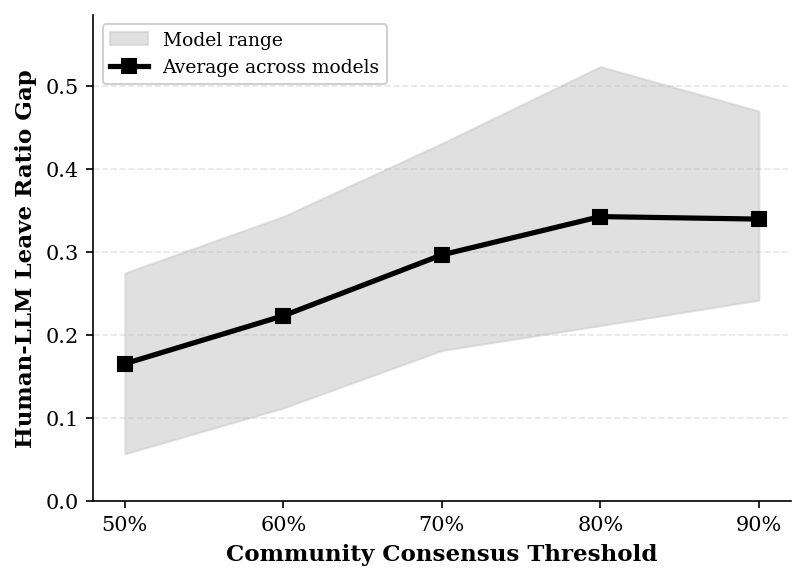

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 4), dpi=150)

# Compute min/max across models for confidence band
model_range = results_df.groupby('threshold')['gap'].agg(['min', 'max', 'mean']).reset_index()

# Plot confidence band (range across models)
ax.fill_between(model_range['threshold'] * 100, 
                model_range['min'], 
                model_range['max'],
                color='#cccccc', alpha=0.6, label='Model range')

# Plot aggregate line
ax.plot(agg_df['threshold'] * 100, agg_df['gap'],
        color='#000000', linewidth=2.5, marker='s', markersize=7,
        label='Average across models', zorder=10)

# Formatting
ax.set_xlabel('Community Consensus Threshold', fontweight='bold')
ax.set_ylabel('Human-LLM Leave Ratio Gap', fontweight='bold')

# X-axis
valid_thresholds = sorted(agg_df['threshold'].unique())
ax.set_xticks([t * 100 for t in valid_thresholds])
ax.set_xticklabels([f'{int(t*100)}%' for t in valid_thresholds])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Y-axis from 0
ax.set_ylim(0, model_range['max'].max() * 1.12)

# Legend
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

## Save Figure

In [19]:
FIGURES.mkdir(parents=True, exist_ok=True)

fig.savefig(FIGURES / 'fig_consensus_divergence.pdf', bbox_inches='tight', dpi=300)
fig.savefig(FIGURES / 'fig_consensus_divergence.png', bbox_inches='tight', dpi=300)

print(f"Saved: {FIGURES / 'fig_consensus_divergence.pdf'}")
print(f"Saved: {FIGURES / 'fig_consensus_divergence.png'}")

Saved: ../figures/fig_consensus_divergence.pdf
Saved: ../figures/fig_consensus_divergence.png


## Summary Statistics for Paper

In [20]:
print("Gap values for paper text:")
for _, row in agg_df.iterrows():
    print(f"  {row['threshold_pct']}: {row['gap']:.2f} (n={row['n_posts']})")

print(f"\nPattern: gap increases from {agg_df['gap'].min():.2f} to {agg_df['gap'].max():.2f}")
print(f"as threshold increases from {int(agg_df['threshold'].min()*100)}% to {int(agg_df['threshold'].max()*100)}%")

Gap values for paper text:
  50%: 0.17 (n=539)
  60%: 0.22 (n=255)
  70%: 0.30 (n=102)
  80%: 0.34 (n=56)
  90%: 0.34 (n=9)

Pattern: gap increases from 0.17 to 0.34
as threshold increases from 50% to 90%
